# Matplotlib介绍


Matplotlib是 Python 最著名的2D/3D绘图库，提供了丰富的数据绘图工具，主要用于绘制一些统计图形。**“Excel能做的，我能做，Excel做不了的，我来做” ：-）**

Matplotlib虽然强大，也有短板，所以衍生出更高级的绘图库：
- Seaborn： 基于Matplotlib，有更好的渲染效果， 更酷！
- plotly: 交互式绘图， 机器学习互动神器


学习常见的疑问：
- Matplotlib看上去很高大上，小白可以简单入手吗？
  - 答：可以。“直觉法”画图 → 稍后传授，了解基本知识点就可以凭直观“随意”构图
- 使用时，看到许多案例， 常常出现plt.xx, ax.xx, fig.xx， 我有点头大犯浑，分不清怎么操作。
  - 答：先了解“2X2”基础知识点，搭建起绘图库运作框架的底层原理。

## 先建立环境 - 导入matplotlib库

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import rcParams
# Setze die chin. Schriftart für den Titel, die in Matpolotlib angezeigt werden kann
rcParams['font.family'] = 'SimHei'  # oder 'Microsoft YaHei'

%load_ext autoreload
%autoreload 2
%matplotlib inline


## Matplotlib入门介绍

需要掌握的**2X2 基础知识点**：

2个框架概念：
1. Matplotlib框架
2. Matplotlib调用API层次


  
Matplotlib框架：架构采用了分层模型（Layer Model），这使得用户能够灵活地创建各种类型的图表： 

3个主要层次+特定的功能和用途：

    脚本层（Scripting Layer）：
        这是用户与 Matplotlib 交互的最高层次，通常通过简单的函数调用来创建图形。
        例如，使用 plt.plot()、plt.show() 等函数来绘制图形。
        这个层次的 API 设计得非常简单，适合快速绘图和实验。

    对象层（Artist/Object Layer）：（又叫容器层）
        核心类型：用户可以直接操作 Matplotlib 的对象（又叫容器），如 Figure、Axes、Axis、Line2D/Text/Patch 等。
        作用： 创建和配置所有可视化元素（渲染），用户可以实现复杂的图形和自定义。
        关键：
        - 使用 fig = plt.figure() 创建一个图形对象，
        - 使用 ax = fig.add_subplot() 添加子图。

    后端层（Backend Layer）：
        作用：Matplotlib 的底层，负责绘图和渲染，并输出到屏幕或文件中。
        核心类型：
        - Figure Canvas：画布
        - Renderer: 渲染引擎（作用： 将指令转换为像素/矢量）
        - Event：处理事件（人机交互，鼠标/键盘）
        Matplotlib 支持多种后端（如 TkAgg、Qt5Agg、Agg 等），用户可以根据需要选择合适的后端。
        


API接口的层次：

了解了Matplotlib 架构，就容易理解和记忆其 API 层次概念，更有效地使用该库进行数据可视化，选择合适的 API 来满足不同的需求。
   

    脚本层：适合快速绘图，使用简单的函数调用。
    对象层：适合需要更高自定义的绘图，用户可以直接操作图形对象 = 用户修仙晋级的核心操作。
    后端层：负责图形的渲染和输出，通常由 Matplotlib 自动处理。用户通常不需要直接与这一层交互。


2个API调用方式：
- 使用静态调用接口， Pyplot接口
- 使用动态调用接口，面向对象的调用接口



### 随心所欲使用Matplotlib画图的心法/建议：
- 记忆这些层次构架的方法 
  - 联想记忆：
    你是一个画家，想象做图的过程。 脚本层：进入画室，支起画架，铺设画布；对象层： 图案排布，形状，颜色等等复杂作画， 随意发挥你的艺术细胞；后端层：颜料，各种画笔。

  - 层次关系：
    记住“从上到下”的关系：用户首先使用简单的脚本层，然后深入到对象层进行自定义，最后由后端层处理渲染。

- 画图过程可以全凭直觉（参考联想记忆的作画过程）



In [18]:
# 示意图加强理解


## API第一种调用方式 - Pyplot接口 静态调用

- 使用的快速原型（Scripting层），
- plt.xx的来源
- 建议：用于快速看图，一般不建议




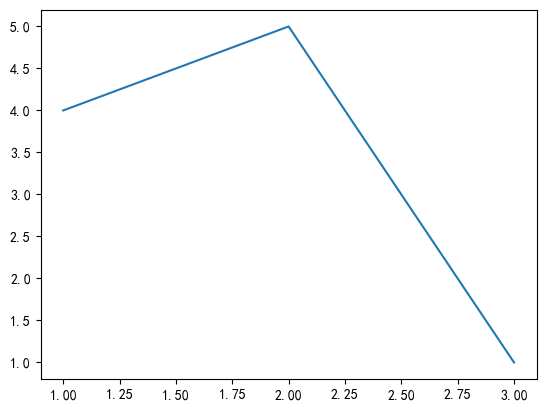

In [21]:
# plt.plot模式，简单调用API
# 三步完成绘图
plt.plot([1,2,3], [4,5,1])  # 创建图形
#plt.title("简单示例")        # 添加标题
#plt.show()                  # 显示图形， 通常在jupyternotebok中自动显示,无需额外表达

## API第二种调用方式 - P面向对象接口 动态调用

核心操作Artist层，最大灵活度渲染图像

### Figures and Subplots -- 面向对象的调用方式的产物

重点介绍 + 建议：主要运用方式

使用面向对象的API调用方法来画图时属于Artist层的必知概念：
- API脚本调用生成的图称之为Plots（大众称谓的一种泛称，和架构层级无关，只为避免中文术语混淆）
  - 所有的Plots在matplotlib里是构建在一个叫 Figure 的对象object数据类中. Figure又称画板。（对比：底层的Canvas称画布）
    - Axes画纸=可视化的具体2D/3D图。 Fig可以有一个或多个Axes
      - 辅助显示层： 如坐标轴(axis) 、图例(legend) 等细节渲染图像层都是建立在Axes之上



### 如果想要构建一个新的figure， 有2种方法：
- 第一种： 使用plt.figure生成一个。 创建时可以留白=空画板， 也可以自定义画板特性

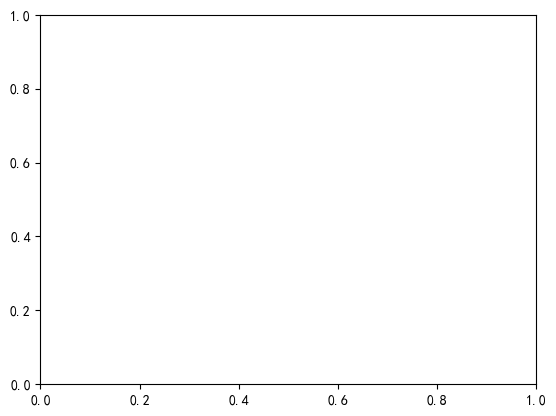

In [25]:
fig = plt.figure()
ax = fig.add_subplot()

- 第二种： 使用plt.subplots同时创建figure和axes, 是一个非常常见的方法 （优雅乎？偷懒乎？）


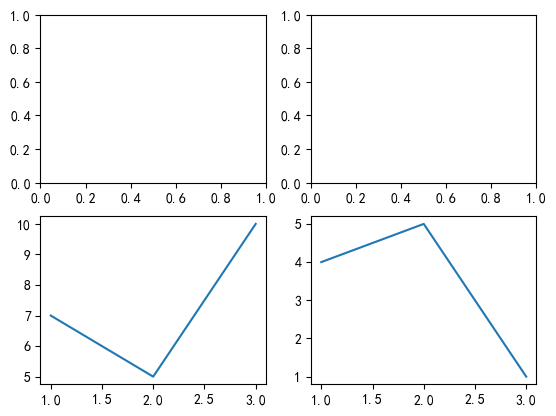

In [45]:
# creates a new figure and returns a NumPy array containing the created subplot objects
fig, axes = plt.subplots(2,2)
#子图索引从0开始，使用axes[行, 列]访问 
axes [1, 1].plot([1,2,3], [4,5,1])  # 在指定的子图上绘制数据
#或者先创建子图，再绘制数据
ax3 = axes[1, 0]
ax3.plot([1,2,3], [7,5,10])  # 在指定的子图上绘制数据 
 

c:\Users\yax3si\.conda\envs\madops\Lib\site-packages\IPython\core\events.py:82: UserWarning:

Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.

c:\Users\yax3si\.conda\envs\madops\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.



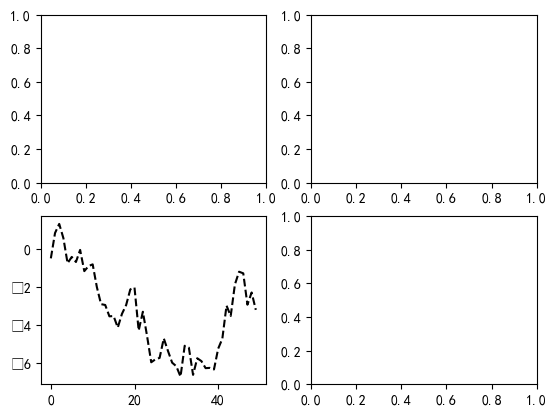

In [30]:
fig = plt.figure()
#像制定表格一样，指明摆放几行几列(顺序为从上到下从左到右)的画纸：
ax1 = fig.add_subplot(221)#2行2列第一个位置
ax2 = fig.add_subplot(222)#2行2列第一个位置
ax3 = fig.add_subplot(223)#2行2列第一个位置
plt.plot(np.random.randn(50).cumsum(), 'k--')
ax4 = fig.add_subplot(224)#2行2列第4个位置


### 微调子图的排版位置和大小

使用对象方法：set_position([left, bottom, width, height]), 其数值取归一化/标准化后在fig中的坐标 （normalized coordinates (0 to 1)).

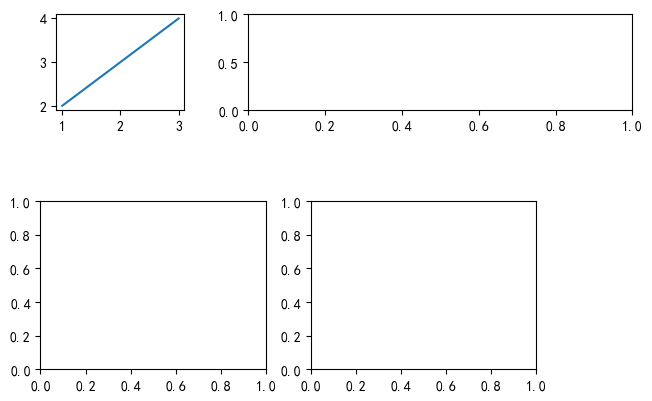

In [7]:
fig, axes = plt.subplots(2,2)
ax1 = axes[0, 0]
ax2 = axes[0, 1] 
# Ändere die Größe und Position von ax1
# set_position erwartet [left, bottom, width, height] in normalized Koordinaten (0 bis 1)
ax1.plot([1, 2, 3], [2, 3, 4])
ax1.set_position([0.15, 0.65, 0.2, 0.2])  # Beispielwerte
ax2.set_position([0.45, 0.65, 0.6, 0.2])  # Beispielwerte 

# Zeige die Plots an
#plt.tight_layout()

### 绘图的创意心法 - 绘制自己的山水画

1. 构思艺术风格
2. 整体构思 = （空间）排版
3. 局部细化渲染 = 绘制每个图像ax

(np.float64(-0.5), np.float64(999.5), np.float64(999.5), np.float64(-0.5))

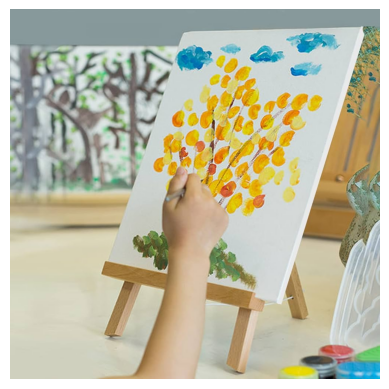

In [22]:
# Imaging you are an artist!
import matplotlib.image as mpimg

# 读取 JPG 图片
img = mpimg.imread('painting_canvas01_.jpg')
plt.imshow(img) 
plt.axis('off')  # 关闭坐标轴显示

### 给刨根问底，追求极致的画匠们

表格总结常用可以修改的画图元素
- Anatomy of a figure

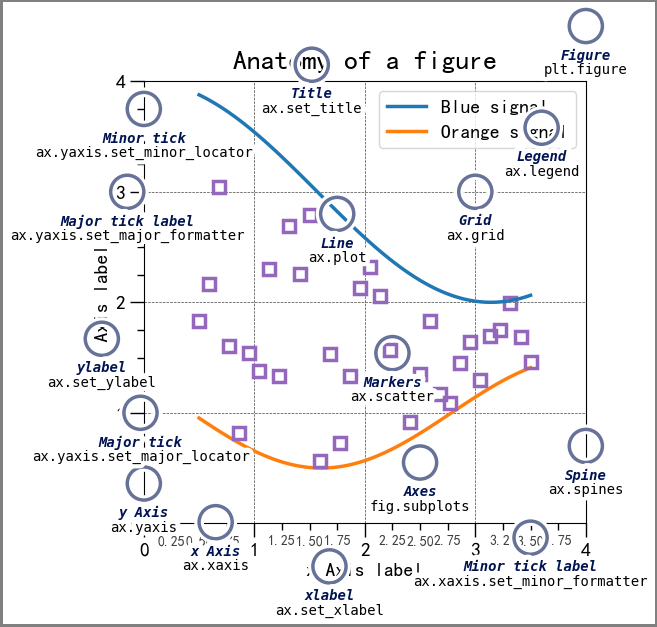

In [9]:
from matplotlib.patches import Circle
from matplotlib.patheffects import withStroke
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

royal_blue = [0, 20/256, 82/256]


# make the figure

np.random.seed(19680801)

X = np.linspace(0.5, 3.5, 100)
Y1 = 3+np.cos(X)
Y2 = 1+np.cos(1+X/0.75)/2
Y3 = np.random.uniform(Y1, Y2, len(X))

fig = plt.figure(figsize=(6.5, 6.5))
ax = fig.add_axes([0.2, 0.17, 0.68, 0.7], aspect=1)

ax.xaxis.set_major_locator(MultipleLocator(1.000))
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_major_locator(MultipleLocator(1.000))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.xaxis.set_minor_formatter("{x:.2f}")

ax.set_xlim(0, 4)
ax.set_ylim(0, 4)

ax.tick_params(which='major', width=1.0, length=10, labelsize=14)
ax.tick_params(which='minor', width=1.0, length=5, labelsize=10,
               labelcolor='0.25')

ax.grid(linestyle="--", linewidth=0.5, color='.25', zorder=-10)

ax.plot(X, Y1, c='C0', lw=2.5, label="Blue signal", zorder=10)
ax.plot(X, Y2, c='C1', lw=2.5, label="Orange signal")
ax.plot(X[::3], Y3[::3], linewidth=0, markersize=9,
        marker='s', markerfacecolor='none', markeredgecolor='C4',
        markeredgewidth=2.5)

ax.set_title("Anatomy of a figure", fontsize=20, verticalalignment='bottom')
ax.set_xlabel("x Axis label", fontsize=14)
ax.set_ylabel("y Axis label", fontsize=14)
ax.legend(loc="upper right", fontsize=14)


# Annotate the figure

def annotate(x, y, text, code):
    # Circle marker
    c = Circle((x, y), radius=0.15, clip_on=False, zorder=10, linewidth=2.5,
               edgecolor=royal_blue + [0.6], facecolor='none',
               path_effects=[withStroke(linewidth=7, foreground='white')])
    ax.add_artist(c)

    # use path_effects as a background for the texts
    # draw the path_effects and the colored text separately so that the
    # path_effects cannot clip other texts
    for path_effects in [[withStroke(linewidth=7, foreground='white')], []]:
        color = 'white' if path_effects else royal_blue
        ax.text(x, y-0.2, text, zorder=100,
                ha='center', va='top', weight='bold', color=color,
                style='italic', fontfamily='monospace',
                path_effects=path_effects)

        color = 'white' if path_effects else 'black'
        ax.text(x, y-0.33, code, zorder=100,
                ha='center', va='top', weight='normal', color=color,
                fontfamily='monospace', fontsize='medium',
                path_effects=path_effects)


annotate(3.5, -0.13, "Minor tick label", "ax.xaxis.set_minor_formatter")
annotate(-0.03, 1.0, "Major tick", "ax.yaxis.set_major_locator")
annotate(0.00, 3.75, "Minor tick", "ax.yaxis.set_minor_locator")
annotate(-0.15, 3.00, "Major tick label", "ax.yaxis.set_major_formatter")
annotate(1.68, -0.39, "xlabel", "ax.set_xlabel")
annotate(-0.38, 1.67, "ylabel", "ax.set_ylabel")
annotate(1.52, 4.15, "Title", "ax.set_title")
annotate(1.75, 2.80, "Line", "ax.plot")
annotate(2.25, 1.54, "Markers", "ax.scatter")
annotate(3.00, 3.00, "Grid", "ax.grid")
annotate(3.60, 3.58, "Legend", "ax.legend")
annotate(2.5, 0.55, "Axes", "fig.subplots")
annotate(4, 4.5, "Figure", "plt.figure")
annotate(0.65, 0.01, "x Axis", "ax.xaxis")
annotate(0, 0.36, "y Axis", "ax.yaxis")
annotate(4.0, 0.7, "Spine", "ax.spines")

# frame around figure
fig.patch.set(linewidth=4, edgecolor='0.5')
plt.show()

- 通用属性设置:
  
  | Artist通用属性 |	作用 | 
  | --------------| ----------|
  | alpha	        | 透明度，0为透明，1为不透明 | 
  | clip_box	    | 裁剪框 |
  | clip_on	      | 是否裁剪 |
  | clip_path	    | 裁剪路径 |
  | label	        | 文本标签 |
  |transform      |	坐标转换(绘制带地图投影的图形需要) |
  |visible	      |是否可见/隐藏(通常用于隐藏Spines，也就是隐藏掉边框) |
  |zorder	        |绘图顺序(用于设置多图层的绘图顺序，比如先填色，再打点，再加图例) |

- 图像核心要素设置
  - 坐标轴相关的设置
    - 标题: ax.set_title('abc')
      - 标题的设置参数：
        | Paramter | values  | Function |
        |----------|---------|----------|
        | loc | {‘center’, ‘left’, ‘right’}| 设置标题显示的位置 |
        | pad |    |  设置标题距离图像上边缘距离 |
        |fontsize |   |  设置字体大小  |
        |color   |   | 设置字体颜色|

    - 设置坐标轴名称: 
       - ax.set_xlabel('x axis')
       - ax.set_ylabel('y axis')
    - 设置x,y轴范围: 
       - ax1.set_xlim(x1, x2) / ax1.set_ylim(y1, y2)
    - 设置刻度及标签:
      - ax1.set_xticks([1,2,3,4])
      - ax1.set_xticklabels(['a','b','c','d'])
      - ax.tick_params(axis = 'y', labelsize=14,direction='in',labelcolor='r')
        | Paramter | values  | Function |
        |----------|---------|----------|
        |axis | 可选{‘x’, ‘y’, ‘both’} | 选择对哪个轴操作，默认是’both’|
        |labelsize |  int |设置刻度标签的大小|
        | direction | {‘in’, ‘out’, ‘inout’} |刻度线的方向 |
        |color |   | 刻度线的颜色  |
        |labelcolor |  |  刻度值颜色 |


    - 设置坐标轴显示与否：
      - ax.spines['top'].set_visible(False)
      - ax.spines['right'].set_visible(False)
    - 常用属性设置(颜色，线性，标记符号)
  
    | 颜色 |	代码 |	线型 |	代码 |	标记	| 代码 |
    |-----|-------|-------|-------|-------|-------|
    | 蓝	|‘b’	  | 实线	|‘-’	  | 点	   |‘.’ |
    |绿	  |‘g’	  | 虚线	|‘–’	  | x	     |‘x’ |
    | 红	|‘r’	  | 虚点	| ‘-.’	| 圆圈	  | ‘o’ |
    | 青	|‘c’	  |点线	  |‘:’	   |三角	| ‘v’ |
    | 紫	|‘p’		|	方块	|‘s’  |  |
    |黄	  |‘y’		|	星	|‘*’  |  |
    |黑	  |‘k’	| 加号	| ‘+’ |  |
    |白	  |‘w’	|	菱形	| ‘D’  |   |

    - 设置图例: ax.legend()
      - loc参数用来规定图例的位置: 如：将图例放在左上角：ax.legend(loc=2)
        | Paramter | values  | 
        |----------|---------|
        |0 | ‘best' |
        |1 | ‘upper right' |
        |2 | ‘upper left' |
        |3 | ‘lower left' |	
        |4 | ‘lower right'|
        |5 | ‘right'|
        |6 | ‘center left'|
        |7 | ‘center right' |
        |8 | ‘lower center' |
        |9 | ‘upper center'|
        |10| ‘center'|

    - 设置网格线: ax.grid()
      - ax.grid(b = True, linestyle = "--",color = "gray", linewidth = "0.5",axis = 'y')
  
      | Paramter | values  | 
      |----------|---------|
      |b | 参数设置是否显示网格|
      |linestyle | 线型 |
      |color |颜色 |
      |linewidth | 宽度 |
      |axis  | x，y，both，显示x/y/两者的格网。默认both|


    - 设置背景颜色:
      - 设置整个图像背景颜色: fig.set_facecolor('white')
      - 设置某个子图背景颜色: ax.set_facecolor('white')

- 保存图像:  fig.savefig
  - 保存图像的时候可以设置分辨率: fig.savefig('xxx.png',dpi=300)


   

### 示例

一个完整的示例，将上面的要素尽量融合（由matplotlib官方例子改编）。


注意：
- 添加属性部分去掉任何一句话都不影响脚本的正确性
- 可以尝试逐句注释，来看看每句话控制着那些要素


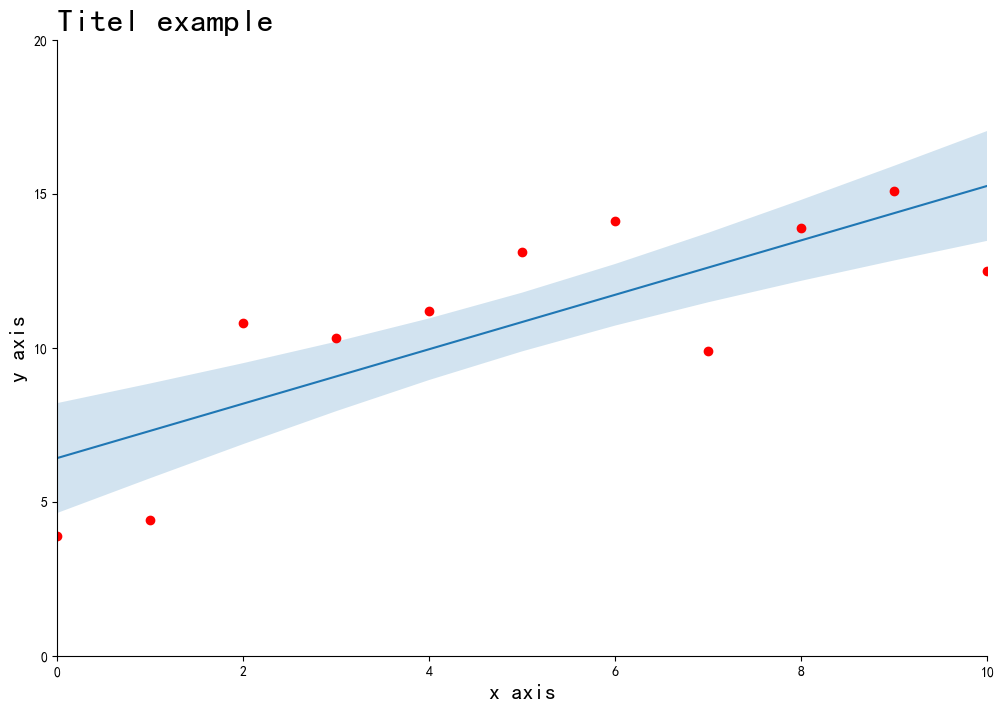

In [27]:
#生成绘图数据部分，跳过即可
N = 21
x = np.linspace(0, 10, 11)
y = [3.9, 4.4, 10.8, 10.3, 11.2, 13.1, 14.1,  9.9, 13.9, 15.1, 12.5]
a, b = np.polyfit(x, y, deg=1)
y_est = a * x + b
y_err = x.std() * np.sqrt(1/len(x) +
                          (x - x.mean())**2 / np.sum((x - x.mean())**2))
#绘图开始
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111)
ax.plot(x, y_est, '-')
ax.fill_between(x, y_est - y_err, y_est + y_err, alpha=0.2)
ax.plot(x, y, 'o', color='r')
#添加属性
ax.set_xlabel('x axis',fontsize =16)
ax.set_ylabel('y axis',fontsize =16)
ax.set_title('Titel example',loc='left', fontsize = 24)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0,10)
ax.set_ylim(0,20)
ax.set_yticks([0,5,10,15,20])
#ax.set_yticklabels(['zero','five','ten'])
plt.show()

## 进阶用法 

### Annotations and Drawing on a Subplot

In addition to the standard plot types, you may wish to draw your own plot annotations, which could consist of text, arrows, or other shapes. You can add annotations
and text using the text, arrow, and annotate functions. text draws text at given coordinates (x, y) on the plot with optional custom styling:

c:\Users\yax3si\.conda\envs\madops\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


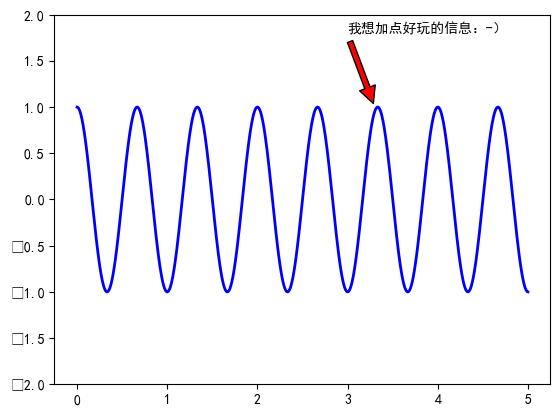

In [28]:
fig, a = plt.subplots() 
  
t = np.arange(0.0, 5.0, 0.001) 
s = np.cos(3 * np.pi * t) 
line = a.plot(t, s, lw = 2, color = 'blue') 
  
# Annotation 
a.annotate('我想加点好玩的信息：-）', xy =(3.3, 1), 
                xytext =(3, 1.8),  
                arrowprops = dict(facecolor ='red', 
                                  shrink = 0.05),) 
  
a.set_ylim(-2, 2) 
  
# Plot the Annotation in the graph 
plt.show()

### Animation Plots

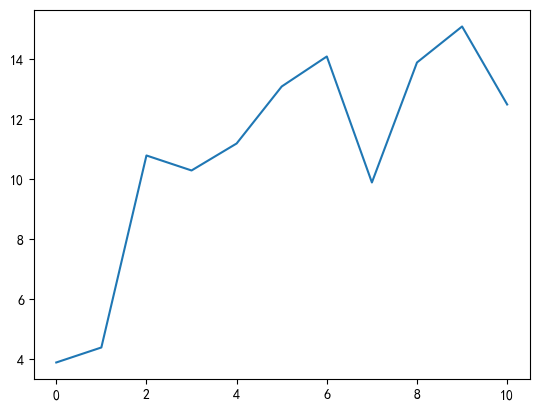

In [29]:
import matplotlib.animation as animation

fig, ax = plt.subplots()
line, = ax.plot(x, y)

def update(num, x, y, line):
    line.set_data(x[:num], y[:num])
    return line,

ani = animation.FuncAnimation(fig, update, len(x), fargs=[x, y, line])

plt.show()

C:\Users\yax3si\AppData\Local\Temp\ipykernel_66892\2931003085.py:13: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  ani = animation.FuncAnimation(
c:\Users\yax3si\.conda\envs\madops\Lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


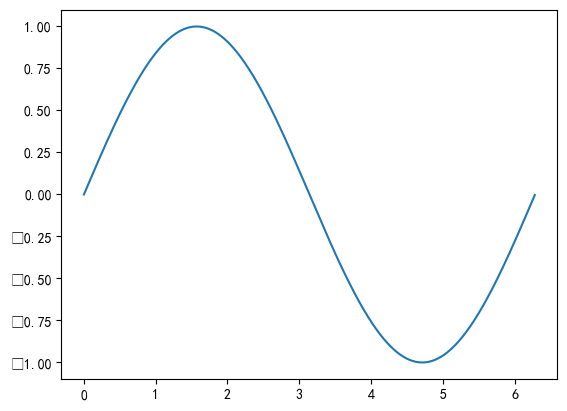

In [30]:
# example from: https://matplotlib.org/stable/gallery/animation/simple_anim.html
fig, ax = plt.subplots()

x = np.arange(0, 2*np.pi, 0.01)
line, = ax.plot(x, np.sin(x))


def animate(i):
    line.set_ydata(np.sin(x + i / 50))  # update the data.
    return line,


ani = animation.FuncAnimation(
    fig, animate, interval=20, blit=True, save_count=50)

plt.show()

## Interactive Visualization 

常用的Python库有：
- plotly 
  - plotly dash: 交互式Dashboard 
- ipywidgets: jupyter notebook下的交换式可视化窗口
  - https://www.elab2go.de/demo-py1/jupyter-notebook-widgets.php

设置：
- plotly: 要在VS Code中显示Plotly图像，必须先要设置适配的Renderer:
    - “”“ Python code
    import plotly.io as pio
    pio.renderers.default = "vscode"
    ”“”
 

In [31]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "vscode"

df = px.data.gapminder()

fig = px.bar(df, x="continent", y="pop", color="continent",
  animation_frame="year", animation_group="country", range_y=[0,4000000000])
fig.show()

In [11]:
# simple example for creating an interactive dashboard using plotly dash 
import plotly.graph_objects as go
# create figure show simply sin/cos functions 
fig = go.Figure()
x = np.linspace(0, 2*np.pi, 40)  
fig.add_trace( go.Scatter(x=x, y=np.sin(x), mode='lines+markers', name='sin'))
fig.add_trace(go.Scatter(x=x, y=np.cos(x), mode='lines+markers', name='cos'))
fig.update_layout(height=400, width=500, 
                  title='Trigonometric Functions', 
                  title_x=0.5, title_y = 0.8, showlegend=True)
# Dashboard creation
from dash import Dash, dcc, html
app = Dash(__name__)
app.layout = html.Div([
    html.H2(children = 'Plotly Dash Demo'),
    html.Div(children='This interactive diagram is created by Plotly Dash.'),
    dcc.Graph(id="graph", figure=fig, animate=True, 
    responsive=True, style={'max-width':'500px'})
], style={'font-family': 'Arial'})
app.run(debug=True)